In [ ]:
import requests
from bs4 import BeautifulSoup
import json
from datetime import datetime

def okdiario_scraper(category):
    if category=="Internacional":
        url = "https://okdiario.com/internacional/feed"
    elif category=="Nacional":
        url = "https://okdiario.com/espana/feed"
    elif category=="Cultura":
        url = "https://okdiario.com/cultura/feed"

    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, 'xml')

    items = soup.find_all('item')
    print(f"Total items: {len(items)}")
    datos = []

    for item in items:
        # Extaer datos
        title = item.find("title").text if item.find("title") else None
        link = item.find("link").text if item.find("link") else None
        date = item.find("pubDate").text if item.find("pubDate") else None
        subtitle = item.find("description").text if item.find("description") else None
        #category = item.find("category").text if item.find("category") else None # Peude salir valencia, españa... mejor pongo nacional para unificarlo después
        
        # Formatear datos
        formatted_date =datetime.strptime(date, "%a, %d %b %Y %H:%M:%S %z").strftime("%Y-%m-%d") # Limpiar fecha

        if subtitle:
            soup_subtitle = BeautifulSoup(subtitle, 'html.parser')
            for link_tag in soup_subtitle.find_all('a'):
                link_tag.decompose()
            subtitle = ' '.join(soup_subtitle.get_text(separator=' ', strip=True).split())

        # Elegir bien el contenido
        content_encoded_list = item.find_all("content:encoded")
        if content_encoded_list:
            html_content = content_encoded_list[-1].text
            soup_content = BeautifulSoup(html_content, 'html.parser')
            
            # Elimina los spans de comentarios
            for span in soup_content.find_all('span', class_='comment-text'):
                span.decompose()
            
            description = soup_content.get_text(separator=' ', strip=True)
        else:
            description = None
        # Guardar datos
        datos.append({
            "Link": link,
            "Periódico": "okdiario",
            "Fecha": formatted_date,
            "Título": title,
            "Subtítulo": subtitle,
            "Categoría": category,
            "Contenido": description
        })
    return(datos)


def guardar_sin_duplicados(nuevos_datos, archivo='data/okdiario.json'):
    # Cargar datos existentes
    try:
        with open(archivo, 'r', encoding='utf-8') as f:
            datos_existentes = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        print(f"Archivo corrupto o no existe. Iniciando desde cero.")
        datos_existentes = []
    
    # Links existentes (para evitar duplicados)
    links_existentes = {item['Link'] for item in datos_existentes}
    
    # Añadir solo nuevos
    nuevos_agregados = 0
    for item in nuevos_datos:
        if item['Link'] not in links_existentes:
            datos_existentes.append(item)
            links_existentes.add(item['Link'])
            nuevos_agregados += 1
    
    # Guardar
    with open(archivo, 'w', encoding='utf-8') as f:
        json.dump(datos_existentes, f, indent=2, ensure_ascii=False)
    
    print(f"Guardados {nuevos_agregados} items nuevos. Total en archivo: {len(datos_existentes)}")

In [ ]:
# Extracción de los datos para las 3 categorías: internacional, nacional, cultura
datos_internacional=okdiario_scraper(category="Internacional")
datos_nacional=okdiario_scraper(category="Nacional")
datos_cultura=okdiario_scraper(category="Cultura")

# Guardar datos
datos_totales = datos_cultura + datos_nacional + datos_internacional
guardar_sin_duplicados(datos_totales)

Total items: 50
Total items: 50
Total items: 50
Guardados 51 items nuevos. Total en archivo: 201


In [ ]:
import json

# Nombre del archivo
archivo = "data/okdiario.json"

# Leer el JSON
with open(archivo, "r", encoding="utf-8") as f:
    datos = json.load(f)

# Modificar la categoría
for noticia in datos:
    if "Categoría" in noticia and isinstance(noticia["Categoría"], str):
        noticia["Categoría"] = noticia["Categoría"].capitalize()

# Guardar el JSON sobrescribiendo el original
with open(archivo, "w", encoding="utf-8") as f:
    json.dump(datos, f, ensure_ascii=False, indent=2)

print("Categorías actualizadas correctamente.")

# Posibles pruebas a implementar

[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


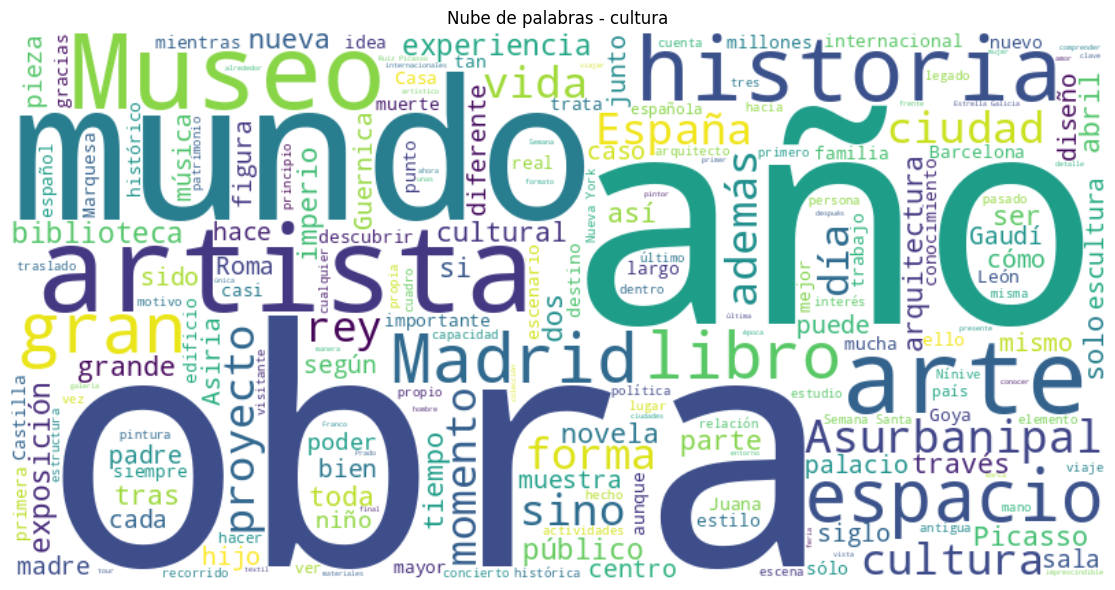

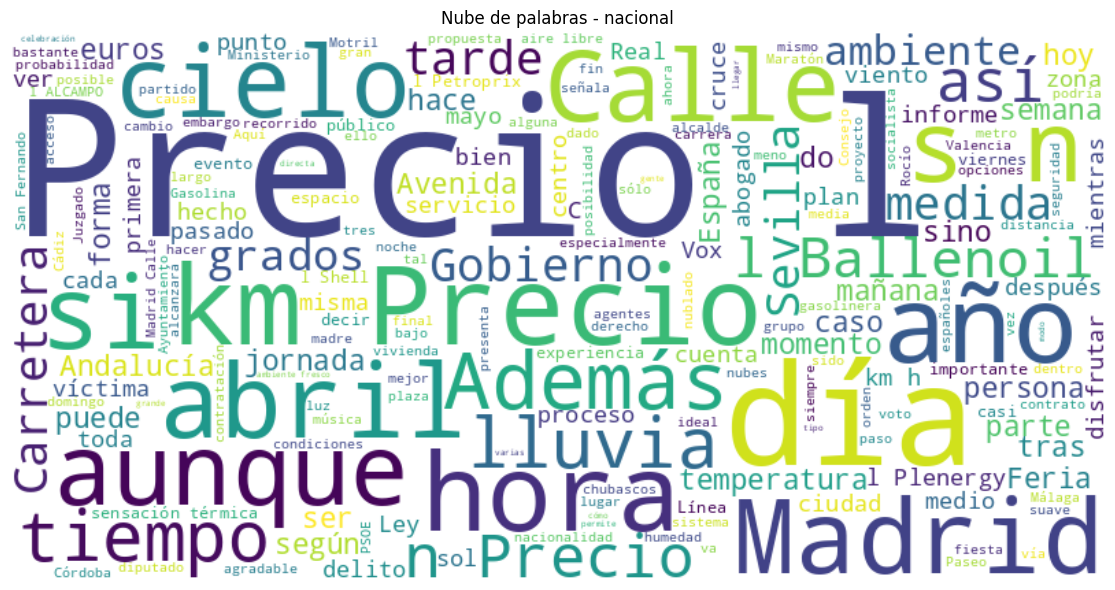

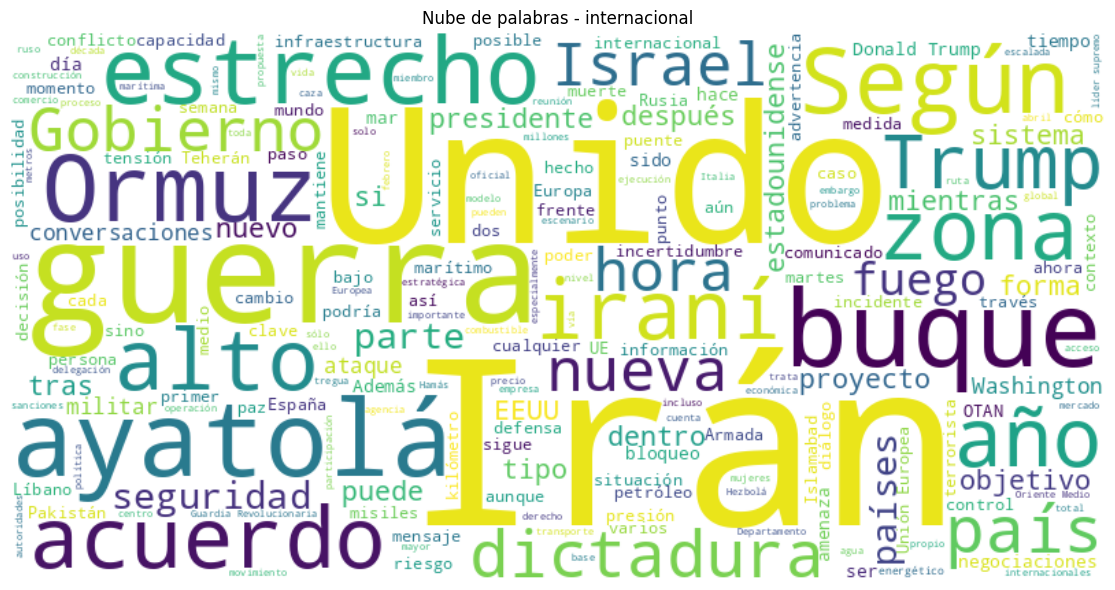

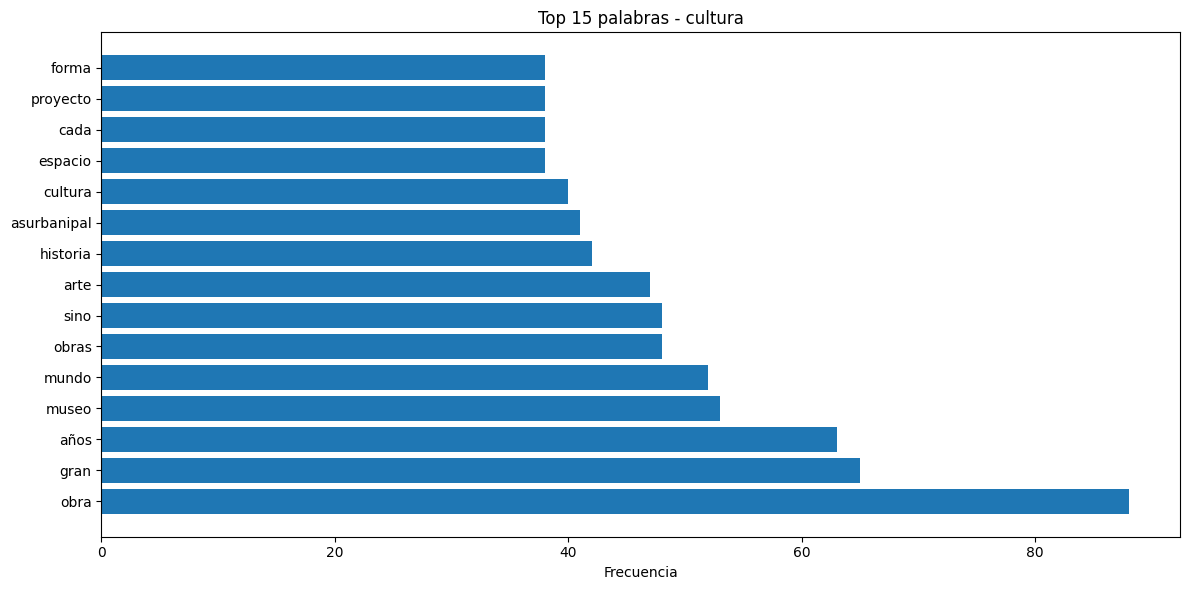

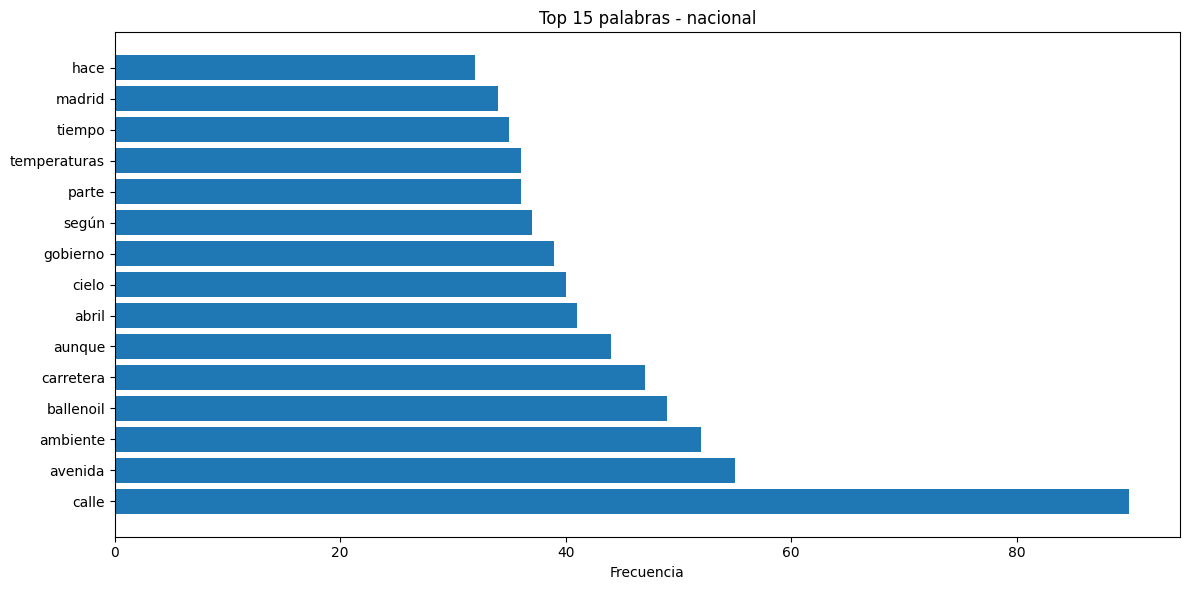

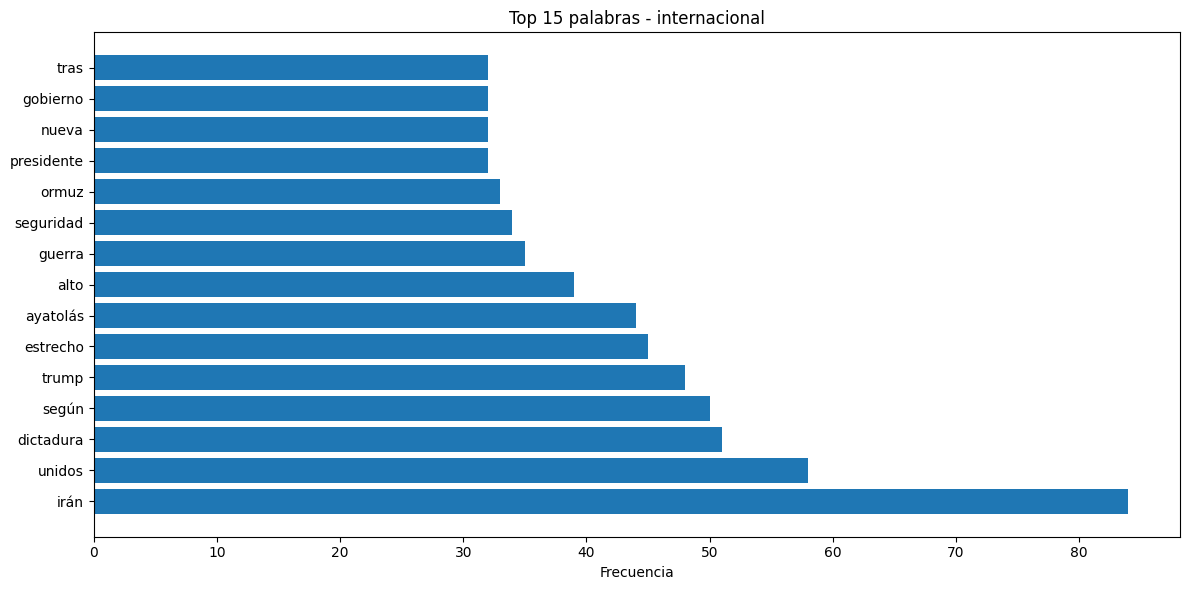

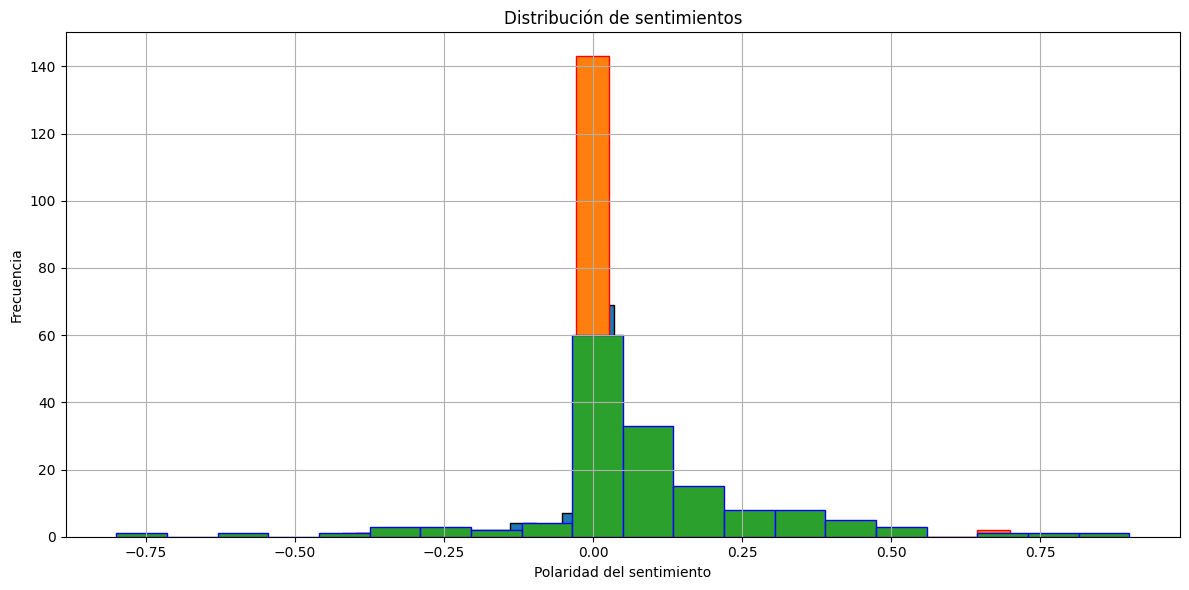

In [29]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Descargar recursos
nltk.download('stopwords')

# Cargar datos
with open('data/okdiario.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)

df = pd.DataFrame(datos)

stop_words = set(stopwords.words('spanish'))

# 2. Nube de palabras por categoría
def plot_nubes_palabras(df):
    for categoria in df['Categoría'].unique():
        texto = ' '.join(df[df['Categoría'] == categoria]['Contenido'].dropna())
        
        wordcloud = WordCloud(
            width=800, 
            height=400, 
            background_color='white',
            stopwords=stop_words
        ).generate(texto)
        
        plt.figure(figsize=(12, 6))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Nube de palabras - {categoria}')
        plt.tight_layout()
        # plt.savefig(f'output/nube_{categoria}.png')
        plt.show()

# 3. Frecuencia de palabras
def plot_palabras_frecuentes(df, top_n=15):
    stop_words_es = set(stopwords.words('spanish'))
    
    for categoria in df['Categoría'].unique():
        texto = ' '.join(df[df['Categoría'] == categoria]['Contenido'].dropna()).lower()
        palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words_es and len(p) > 3]
        
        frecuencias = Counter(palabras).most_common(top_n)
        palabras_list, counts = zip(*frecuencias)
        
        plt.figure(figsize=(12, 6))
        plt.barh(palabras_list, counts)
        plt.xlabel('Frecuencia')
        plt.title(f'Top {top_n} palabras - {categoria}')
        plt.tight_layout()
        # plt.savefig(f'output/palabras_{categoria}.png')
        plt.show()

# 3. Frecuencia de palabras
def plot_palabras_frecuentes(df, top_n=15):
    stop_words = set(stopwords.words('spanish'))
    
    for categoria in df['Categoría'].unique():
        texto = ' '.join(df[df['Categoría'] == categoria]['Contenido'].dropna()).lower()
        palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words and len(p) > 3]
        
        frecuencias = Counter(palabras).most_common(top_n)
        palabras_list, counts = zip(*frecuencias)
        
        plt.figure(figsize=(12, 6))
        plt.barh(palabras_list, counts)
        plt.xlabel('Frecuencia')
        plt.title(f'Top {top_n} palabras - {categoria}')
        plt.tight_layout()
        # plt.savefig(f'output/palabras_{categoria}.png')
        plt.show()

# 4. Análisis de sentimientos
def analizar_sentimientos(df):
    sentimientos = []
    
    for idx, row in df.iterrows():
        titulo_sentiment = TextBlob(row['Título']).sentiment.polarity
        contenido_sentiment = TextBlob(row['Contenido']).sentiment.polarity
        
        sentimientos.append({
            'Título': row['Título'],
            'Categoría': row['Categoría'],
            'Sentimiento_Título': titulo_sentiment,
            'Sentimiento_Contenido': contenido_sentiment,
            'Promedio': (titulo_sentiment + contenido_sentiment) / 2
        })
    
    df_sentimientos = pd.DataFrame(sentimientos)
    
    # Histograma de sentimientos
    plt.figure(figsize=(12, 6))
    df_sentimientos['Promedio'].hist(bins=20, edgecolor='black')
    df_sentimientos['Sentimiento_Título'].hist(bins=20, edgecolor='red')
    df_sentimientos['Sentimiento_Contenido'].hist(bins=20, edgecolor='blue')
    plt.xlabel('Polaridad del sentimiento')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de sentimientos')
    plt.tight_layout()
    # plt.savefig('output/sentimientos_distribucion.png')
    plt.show()
    
    return df_sentimientos

# Ejecutar
plot_nubes_palabras(df)
plot_palabras_frecuentes(df)
df_sentimientos = analizar_sentimientos(df)

In [30]:
import torch
print(f"PyTorch disponible: {torch.cuda.is_available()}")

from transformers import pipeline
import matplotlib.pyplot as plt
# Modelo en español
sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0 if torch.cuda.is_available() else -1
)


PyTorch disponible: True


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1264.56it/s]


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


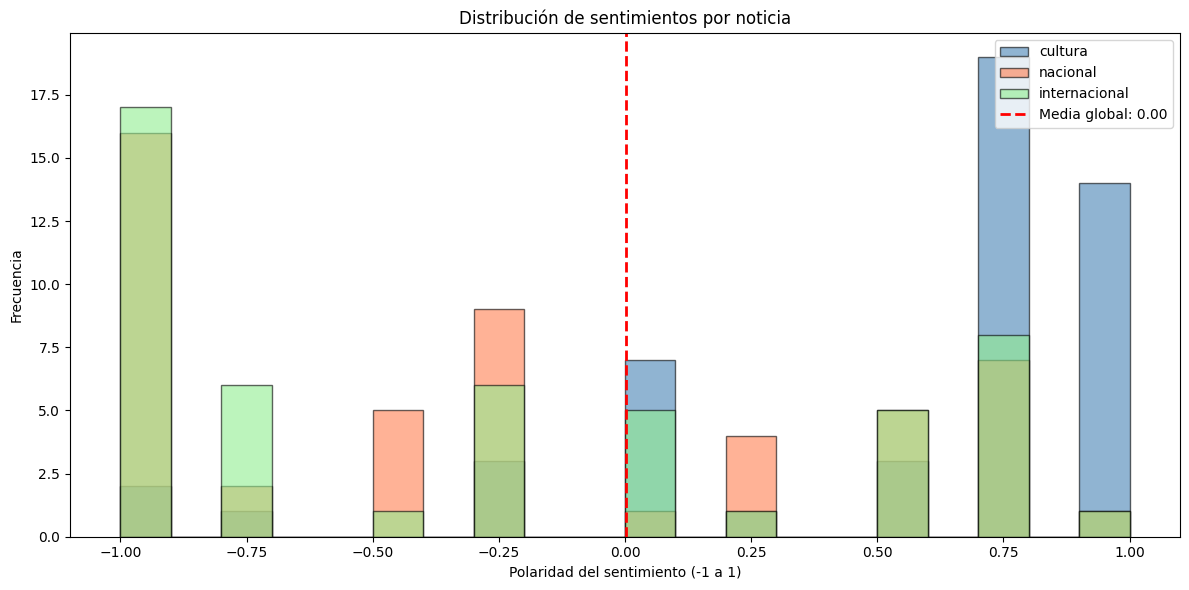

<Figure size 1200x600 with 0 Axes>

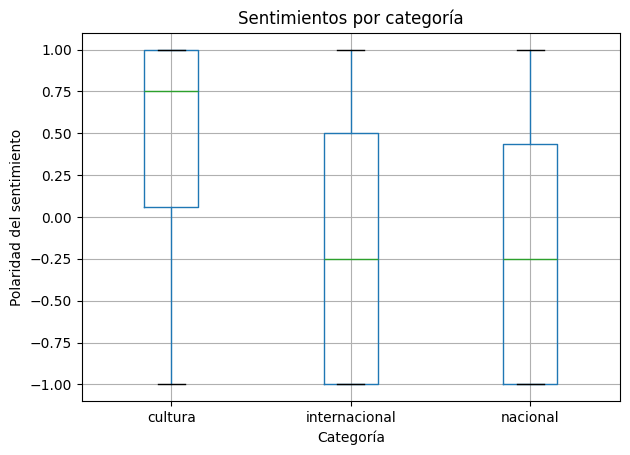

In [31]:
def analizar_sentimientos(df):
    sentimientos = []
    
    for idx, row in df.iterrows():
        titulo = row['Título'][:512]
        contenido = row['Contenido'][:512]
        
        try:
            resultado_titulo = sentiment_pipeline(titulo)[0]
            resultado_contenido = sentiment_pipeline(contenido)[0]
            
            titulo_score = (int(resultado_titulo['label'].split()[0]) - 3) / 2
            contenido_score = (int(resultado_contenido['label'].split()[0]) - 3) / 2
            
        except Exception as e:
            print(f"Error en fila {idx}: {e}")
            titulo_score, contenido_score = 0, 0
        
        sentimientos.append({
            'Título': row['Título'],
            'Categoría': row['Categoría'],
            'Sentimiento_Título': titulo_score,
            'Sentimiento_Contenido': contenido_score,
            'Promedio': (titulo_score + contenido_score) / 2
        })
    
    df_sentimientos = pd.DataFrame(sentimientos)
    
    # Histograma de sentimientos
    plt.figure(figsize=(12, 6))

    categorias = df_sentimientos['Categoría'].unique()
    colores = ['steelblue', 'coral', 'lightgreen', 'gold', 'plum']  # Añade más si necesitas

    for i, categoria in enumerate(categorias):
        datos_categoria = df_sentimientos[df_sentimientos['Categoría'] == categoria]['Promedio']
        plt.hist(datos_categoria, bins=20, edgecolor='black', color=colores[i % len(colores)], alpha=0.6, label=categoria)

    plt.xlabel('Polaridad del sentimiento (-1 a 1)')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de sentimientos por noticia')
    plt.axvline(df_sentimientos['Promedio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media global: {df_sentimientos["Promedio"].mean():.2f}')
    plt.legend()
    plt.tight_layout()
    # plt.savefig('output/sentimientos_distribucion.png')
    plt.show()
    
    # Box plot por categoría
    plt.figure(figsize=(12, 6))
    df_sentimientos.boxplot(column='Promedio', by='Categoría')
    plt.xlabel('Categoría')
    plt.ylabel('Polaridad del sentimiento')
    plt.title('Sentimientos por categoría')
    plt.suptitle('')
    plt.tight_layout()
    # plt.savefig('output/sentimientos_por_categoria.png')
    plt.show()
    
    return df_sentimientos 
df_sentimientos = analizar_sentimientos(df)


Cosas que ha dicho en clase que pueden estar bien implementar:

Probar a ahacer Named Entity Recognition

hacer el test sentimientos pero para chuncks del texto, no del todo texto de golpe

Modelo de espacio de vectores

Ver probabilidad de aparición de la palabras